# Cardiac Digital Twin Summer School (CaDiTSS)

# Cardiac Image Analysis and Mesh Fitting

In this practical session, we will build a deep learning-based processing pipeline for cine cardiac magnetic resonance (CMR) image analysis and mesh fitting. This practical session will work through the following steps:

- Automated CMR image segmentation.
- CMR image-derived phenotypes calculation and analysis.
- Bi-ventricular heart mesh template construction.
- Bi-ventricular heart mesh fitting using a deep learning-based approach.

# Part II. Cardiac Mesh Fitting

![Cardiac Mesh Fitting](https://raw.githubusercontent.com/m-qiang/CaDiTSS/main/figures/mesh_fitting.png)

In [ ]:
# install required dependencies
!pip install trimesh
!pip install pymeshlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.4/750.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 MB 8.9 MB/s eta 0:00:00


In [ ]:
import os
import glob
import random
import numpy as np
from tqdm.notebook import tqdm
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# packages for 3D geometric processing
from skimage.measure import marching_cubes
import trimesh
import pymeshlab

In [ ]:
# download the dataset again
os.environ["HF_HUB_DISABLE_XET"] = "1"
from huggingface_hub import snapshot_download

data_dir = snapshot_download(
    repo_id="msepulvedagodoy/ACDC",
    repo_type="dataset",
    local_dir="./ACDC"
)

print(f"Dataset downloaded to: {data_dir}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1054 files:   0%|          | 0/1054 [00:00<?, ?it/s]

Dataset downloaded to: /content/ACDC


## 1. 3D CMR Volume Preprocessing

In the previous part, we trained a 2D U-Net for cardiac MR segmentation and analysis. In this part, we move from 2D segmentation to
**3D cardiac mesh fitting**.

Before fitting a mesh, the 3D CMR images and segmentation volumes need to be aligned into a consistent spatial representation. In the ACDC dataset, different subjects may have different heart sizes, image dimensions, orientations, and voxel spacings. Therefore, the first step is to spatially align and standardise the 3D CMR volumes and their segmentations, so that all subjects share a consistent image size, orientation, and spatial resolution.

In [ ]:
def compute_mean_volume(seg_paths: str) -> float:
    """
    compute the mean heart volume from a dataset for rescaling

    Args
    - seg_paths: paths of segmentation masks

    Returns
    - mean_volume: mean volume (mL)
    """
    volume_list = []

    for seg_path in tqdm(train_seg_paths):

        seg_nii = nib.load(seg_path)
        seg = seg_nii.get_fdata()
        voxel_size = seg_nii.header.get_zooms()[:3]

        # compute average heart volume
        volume = np.sum(seg > 0) * np.prod(voxel_size) * 1e-3
        volume_list.append(volume)

    mean_volume = np.mean(volume_list)

    return mean_volume

In [ ]:
def crop_and_pad(
    img_tensor: torch.Tensor,
    img_center: tuple[int,int,int] = (64, 64, 48),
    img_size: tuple[int,int,int] = (128, 128, 96),
) -> torch.Tensor :
    """
    crop and pad image based on provided image center and size

    Args
    - img_tensor: input image tensor (B,X,Y,Z)
    - img_center: center for cropping and padding
    - img_size: target image size after cropping and padding

    Returns
    - img_resize: resized image after cropping and padding
    """
    device = img_tensor.device

    # np.ndarray -> torch.Tensor
    # target image size
    img_size = torch.as_tensor(img_size, device=device).long()
    # original image size
    orig_size = torch.as_tensor(img_tensor.shape[1:], device=device).long()

    # coordinates for crop
    start = img_center.long() - img_size // 2
    end = start + img_size

    # clip within the image
    src_start = torch.clamp(start, min=0)
    src_end = torch.minimum(end, orig_size)

    # crop
    img_resize = img_tensor[
        :,
        src_start[0]:src_end[0],
        src_start[1]:src_end[1],
        src_start[2]:src_end[2]
    ]

    # pad
    pad_before = torch.clamp(-start, min=0)
    pad_after = torch.clamp(end - orig_size, min=0)

    # F.pad uses (Z, Y, X) order
    img_resize = F.pad(img_resize, (
        pad_before[2], pad_after[2],
        pad_before[1], pad_after[1],
        pad_before[0], pad_after[0],
    ))

    return img_resize


In [ ]:
def rotate(
    img_tensor: torch.Tensor,
    d_src: torch.Tensor,
    d_dst: torch.Tensor,
    mode: str = "nearest",
) -> torch.Tensor:
    """
    Rotate a 3D volume along z-axis.

    Args
    - img_tensor: 3D volume of shape [B, C, H, W, D]
    - d_src: source direction from LV to RV
    - d_dst: target direction
    - mode: interpolation mode ["bilinear", "nearest"]

    Returns
    - img_rotate: rotated volume with the same shape as input.
    """
    B = img_tensor.shape[0]  # batch size
    device = img_tensor.device
    dtype = img_tensor.dtype

    # compute sin(theta) and cos(theta) for rotation
    c = d_src @ d_dst
    s = d_src[0] * d_dst[1] - d_src[1] * d_dst[0]

    # define rotation matrix
    R = torch.tensor([
        [1,  0,  0, 0],
        [0,  c, -s, 0],
        [0,  s,  c, 0],
    ], device=device, dtype=dtype)

    # same transformation for every item in batch
    theta = R.unsqueeze(0).repeat(B, 1, 1)

    # define PyTorch affine grid for grid sampling
    grid = F.affine_grid(
        theta,
        img_tensor.size(),
        align_corners=False
    )

    # grid sampling for rotation
    img_rotate = F.grid_sample(
        img_tensor,
        grid,
        mode=mode,
        padding_mode="zeros",
        align_corners=False
    )

    return img_rotate

In [ ]:
def preprocess(
    img: torch.Tensor,
    seg: torch.LongTensor,
    mean_volume: float,
    orig_voxel_size: tuple[float,float,float] = (1.8, 1.8, 10.0),
    resample_voxel_size: tuple[float,float,float] = (1.5, 1.5, 1.5),
    crop_pad_size: tuple[int,int,int] = (128, 128, 128)
) -> tuple[torch.Tensor, torch.LongTensor]:
    """
    Standardise a 3D CMR image and segmentation for mesh fitting.

    The preprocessing includes:

    1. Resample to isotropic voxel spacing.
    2. Rescale the heart to a mean cardiac volume.
    3. Crop and pad to a fixed volume size.
    4. Rotate the volume to align the LV-to-RV direction.

    Args
    - img: input CMR volume with shape (B, X, Y, Z).
    - seg : corresponding segmentation with shape (B, X, Y, Z).
    - mean_volume: reference heart volume (mL) used for rescaling.
    - orig_voxel_size: original voxel spacing in mm.
    - resample_voxel_size: target voxel spacing in mm.
    - crop_pad_size: final spatial dimensions of the preprocessed volume.

    Returns
    - img: preprocessed CMR volume.
    - seg: preprocessed segmentation.
    """
    device = img.device

    # ---------------------------------------------------------
    # resampling and rescaling
    # ---------------------------------------------------------
    # compute heart volume for rescaling
    heart_volume = (seg > 0).sum().item() * np.prod(orig_voxel_size) / 1000
    # resample to target resolution, e.g., 1.8 x 1.8 x 10 -> 1.5 x 1.5 x 1.5
    scale_factor = np.array(orig_voxel_size) / np.array(resample_voxel_size)
    # rescale to the reference size
    scale_factor *= np.cbrt(mean_volume / heart_volume)

    # perform resampling by interpolation
    img = F.interpolate(
        img.unsqueeze(1),
        scale_factor=list(scale_factor),
        mode="trilinear"
    ).squeeze(1)

    seg = F.interpolate(
        seg.unsqueeze(1),
        scale_factor=list(scale_factor),
        mode="nearest"
    ).squeeze(1)

    # ---------------------------------------------------------
    # cropping and padding
    # ---------------------------------------------------------
    # volume center for cropping and padding
    img_center = torch.stack(torch.where(seg[0]>0)).float().mean(-1)

    # crop and pad all volume to the same size
    img = crop_and_pad(
        img,
        img_center=img_center,
        img_size=crop_pad_size
    )

    seg = crop_and_pad(
        seg,
        img_center=img_center,
        img_size=crop_pad_size
    )

    # ---------------------------------------------------------
    # rotating LV-to-RV direction to a fixed direction
    # ---------------------------------------------------------
    # rotate all volume to the same direction
    center_lv = torch.stack(torch.where(seg[0]==3)).float().mean(-1)
    center_rv = torch.stack(torch.where(seg[0]==1)).float().mean(-1)

    # compute source direction from LV to RV
    d_src = (center_rv - center_lv)[:2]
    d_src = d_src / d_src.norm()

    # target direction
    d_dst = torch.Tensor([-1,0]).float().to(device)

    # rotate along z-axis
    img = rotate(img.unsqueeze(1), d_src, d_dst, mode="bilinear")[:,0]
    seg = rotate(seg.unsqueeze(1), d_src, d_dst, mode="nearest")[:,0]

    return img.float(), seg.long()


## 2. Construct Bi-ventricular Mesh Template

We construct a **bi-ventricular mesh template** that represents the average cardiac anatomy and can be fitted to individual subjects. First, a template segmentation is created by averaging the preprocessed segmentations from the training set. A surface mesh is then extracted from this template segmentation to construct the bi-ventricular template mesh used for mesh fitting.

### Construct segmentation template

In [ ]:
def split_patients(
    data_dir: str,
    train_ratio: float = 0.8,
    seed: int = 42
) -> tuple[list[str], list[str]]:
    """
    Split patient folders into training and validation sets.

    Args
    - data_dir: directory containing the ACDC patient folders.
    - train_ratio: ratio of patients used for training.
    - seed: random seed for reproducibility.

    Returns
    - train_patient_paths: training patient paths.
    - val_patient_paths: validation patient paths.
    """
    patient_paths = sorted(
        glob.glob(os.path.join(data_dir, "patient*"))
    )

    random.seed(seed)
    random.shuffle(patient_paths)

    split_idx = int(len(patient_paths) * train_ratio)

    train_patient_paths = patient_paths[:split_idx]
    val_patient_paths = patient_paths[split_idx:]

    return train_patient_paths, val_patient_paths


def get_pairs_from_patients(
    patient_paths: list[str]
) -> tuple[list[str], list[str]]:
    """
    Collect paired CMR image and segmentation paths from patient paths.

    Args
    - patient_paths: list of ACDC patient paths.

    Returns
    - img_paths: paths to CMR images.
    - seg_paths: paths to corresponding ground-truth segmentations.
    """

    img_paths = []
    seg_paths = []

    for patient_path in patient_paths:

        # Find all ground-truth segmentation files
        seg_files = sorted(glob.glob(os.path.join(patient_path, "*_gt.nii.gz")))

        for seg_path in seg_files:
            # The corresponding MRI has the same filename without the "_gt" suffix
            img_path = seg_path.replace("_gt.nii.gz", ".nii.gz")

            # Add the pair only if the MRI file exists
            if os.path.exists(img_path):
                img_paths.append(img_path)
                seg_paths.append(seg_path)

    return img_paths, seg_paths

In [ ]:
# load ACDC training data
data_dir = "./ACDC/training"
train_patient_paths, val_patient_paths = split_patients(data_dir)
train_img_paths, train_seg_paths = get_pairs_from_patients(train_patient_paths)
val_img_paths, val_seg_paths = get_pairs_from_patients(val_patient_paths)

  0%|          | 0/160 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Original image size:  (174, 224, 12)
Processed image size: (128, 128, 96)


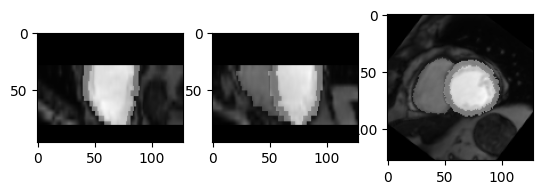

Original image size:  (224, 256, 10)
Processed image size: (128, 128, 96)


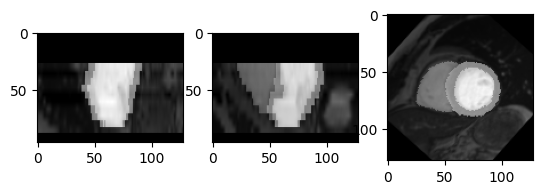

Original image size:  (256, 256, 8)
Processed image size: (128, 128, 96)


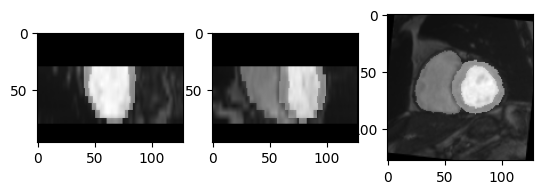

Original image size:  (256, 216, 9)
Processed image size: (128, 128, 96)


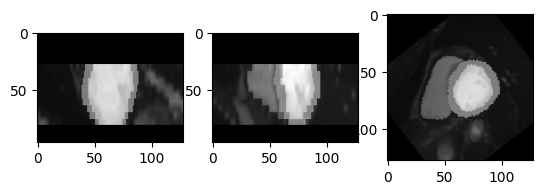

Original image size:  (216, 256, 10)
Processed image size: (128, 128, 96)


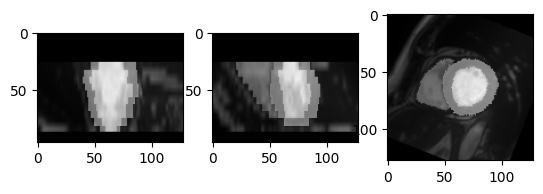

Original image size:  (248, 256, 10)
Processed image size: (128, 128, 96)


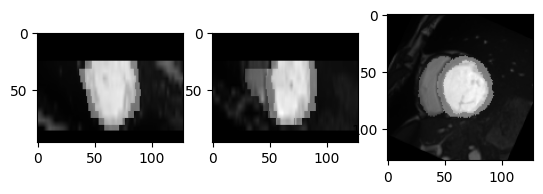

Original image size:  (208, 256, 10)
Processed image size: (128, 128, 96)


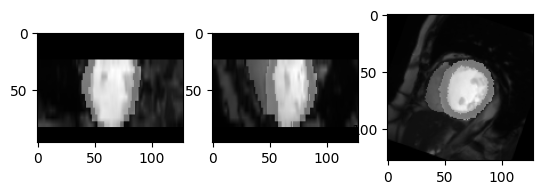

Original image size:  (208, 256, 8)
Processed image size: (128, 128, 96)


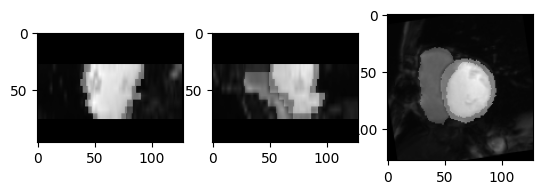

Original image size:  (216, 256, 7)
Processed image size: (128, 128, 96)


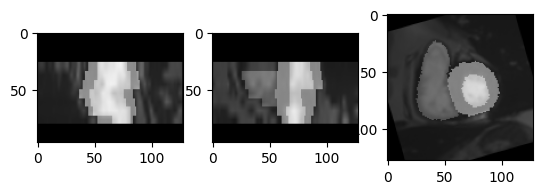

Original image size:  (256, 216, 10)
Processed image size: (128, 128, 96)


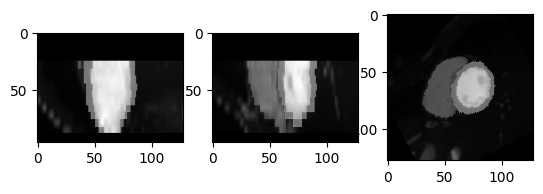

Original image size:  (216, 304, 8)
Processed image size: (128, 128, 96)


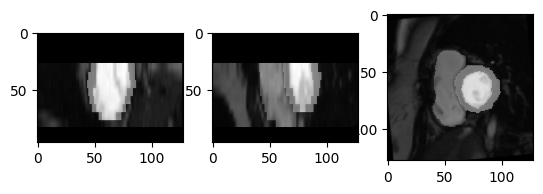

Original image size:  (208, 256, 9)
Processed image size: (128, 128, 96)


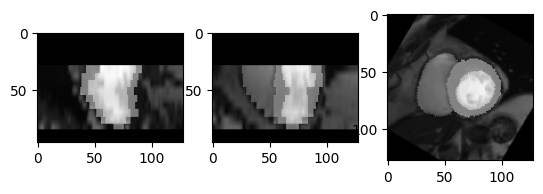

Original image size:  (256, 256, 9)
Processed image size: (128, 128, 96)


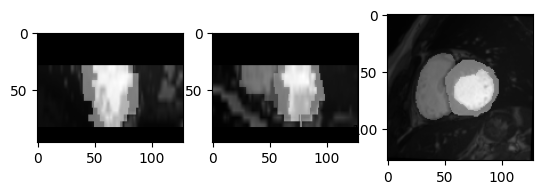

Original image size:  (208, 256, 8)
Processed image size: (128, 128, 96)


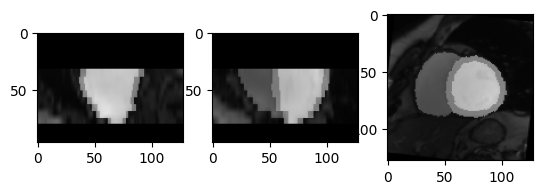

Original image size:  (216, 256, 10)
Processed image size: (128, 128, 96)


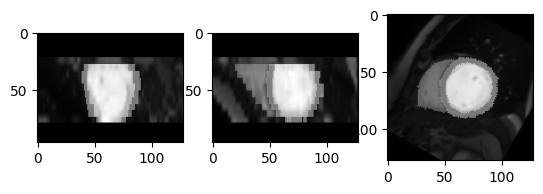

Original image size:  (154, 224, 7)
Processed image size: (128, 128, 96)


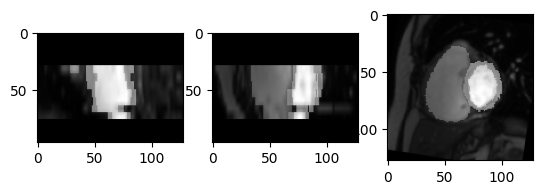

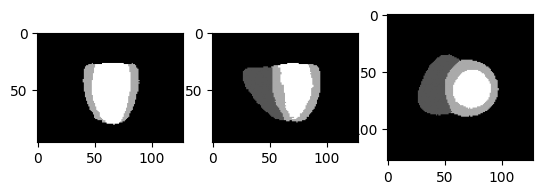

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# initialise one-hot average segmentation
seg_template_onehot = 0
# compute mean heart volume of training data
mean_volume = compute_mean_volume(train_seg_paths)

# ---------------------------------------------------------
# Compute the average segmentation map of training data
# ---------------------------------------------------------
for idx, (img_path, seg_path) in tqdm(
    enumerate(zip(train_img_paths, train_seg_paths))
):
    img = nib.load(img_path).get_fdata()
    orig_img_size = img.shape

    seg_nii = nib.load(seg_path)
    seg = seg_nii.get_fdata()
    orig_voxel_size = seg_nii.header.get_zooms()[:3]

    # (X,Y,Z) -- > (1,X,Y,Z)
    img = torch.from_numpy(img[None]).float().to(device)
    seg = torch.from_numpy(seg[None]).float().to(device)

    # run proprocessing to align all 3D image and segmentation volumes
    img, seg = preprocess(
        img,
        seg,
        mean_volume=mean_volume,
        orig_voxel_size=orig_voxel_size,
        resample_voxel_size=(1.5, 1.5, 1.5),
        crop_pad_size=(128, 128, 96)
    )

    # compute the average segmentation across all dataset
    seg_template_onehot += F.one_hot(seg.long(), num_classes=4).float().mean(0)

    # visualise aligned 3D image and segmentation volumes
    if idx % 10 == 0:
        img = img[0].cpu().numpy()
        seg = seg[0].cpu().numpy()
        print("Original image size: ", orig_img_size)
        print("Processed image size:", img.shape)
        plt.subplot(1,3,1)
        plt.imshow(img[75].T, cmap="gray")
        plt.imshow(seg[75].T, alpha=0.6, vmin=0, vmax=3, cmap="gray")
        plt.subplot(1,3,2)
        plt.imshow(img[:,75].T, cmap="gray")
        plt.imshow(seg[:,75].T, alpha=0.6, vmin=0, vmax=3, cmap="gray")
        plt.subplot(1,3,3)
        plt.imshow(img[:,:,40].T, cmap="gray")
        plt.imshow(seg[:,:,40].T, alpha=0.6, vmin=0, vmax=3, cmap="gray")
        plt.show()

# ---------------------------------------------------------
# Create segmentation template
# ---------------------------------------------------------
seg_template_onehot /= len(train_seg_paths)
seg_template_onehot = seg_template_onehot.cpu().numpy()
seg_template = seg_template_onehot.argmax(-1)

plt.subplot(1,3,1)
plt.imshow(seg_template[75].T, vmin=0, vmax=3, cmap="gray")
plt.subplot(1,3,2)
plt.imshow(seg_template[:,75].T, vmin=0, vmax=3, cmap="gray")
plt.subplot(1,3,3)
plt.imshow(seg_template[:,:,40].T, vmin=0, vmax=3, cmap="gray")
plt.show()


### Construct mesh template

A **surface mesh** is represented as $M = (V, E, F)$ where:

- $V = \{v_i\}$ is the set of **vertices**, with each vertex $v_i = (x_i, y_i, z_i)$ defining a point in 3D space.
- $E = \{e_{ij}\}$ is the set of **edges** connecting neighbouring vertices.
- $F = \{f_k\}$ is the set of **faces** describing the surface elements.

For a triangular mesh, each face is defined by three connected vertices. Together, the vertices, edges, and faces provide a discrete geometric representation of the cardiac surface. Compared with a voxel-based segmentation, a mesh provides an explicit representation of the anatomical boundary, making it suitable for cardiac shape and motion analysis.

![Triangle mesh](https://commons.wikimedia.org/wiki/Special:FilePath/Dolphin_triangle_mesh.png)

We extract a **bi-ventricular mesh template** from the template segmentation in following steps:

- **Surface extraction** - We first apply the **Marching Cubes** algorithm (https://dl.acm.org/doi/10.1145/37402.37422) to the template segmentation. Marching Cubes extracts the boundaries of the segmented cardiac structures and represents them as triangular meshes.

- **Remeshing** - The initial mesh produced by marching cubes may contain many irregularly shaped or unevenly distributed triangles. We therefore perform remeshing to obtain a more regular vertex distribution and improve the quality of the template mesh.

- **Mesh smoothing** - Finally, mesh smoothing is applied to reduce voxelisation artefacts and small surface irregularities while preserving the overall cardiac shape.


In [ ]:
# ---------------------------------------------------------
# extract initial template mesh using Marching Cubes algorithm
# ---------------------------------------------------------
# LV - LV endocardial surface
# MY - LV epicardial  surface
# RV - RV endocardial surface

level = 0.4
vert_lv, face_lv = marching_cubes(seg_template_onehot[...,3], level=level)[:2]
vert_my, face_my = marching_cubes(seg_template_onehot[...,[2,3]].sum(-1), level=level)[:2]
vert_rv, face_rv = marching_cubes(seg_template_onehot[...,1], level=level)[:2]

vert_lv = vert_lv.copy()
vert_my = vert_my.copy()
vert_rv = vert_rv.copy()

face_lv = face_lv[:,::-1].copy()
face_my = face_my[:,::-1].copy()
face_rv = face_rv[:,::-1].copy()

print("LV mesh number of vertices:", vert_lv.shape[0])
print("MY mesh number of vertices:", vert_my.shape[0])
print("RV mesh number of vertices:", vert_rv.shape[0])

LV mesh number of vertices: 8818
MY mesh number of vertices: 13772
RV mesh number of vertices: 9890


In [ ]:
# ---------------------------------------------------------
# mesh visualisation
# ---------------------------------------------------------
def set_color(
    mesh: trimesh.Trimesh,
    color: tuple[float, float, float],
    alpha: float = 0.3
) -> trimesh.Trimesh:
    """
    Set color and transparency

    Args
    - mesh: trimesh.Mesh object
    - color: mesh color
    - alpha: transparency

    Returns
    - mesh: mesh with color and transparency
    """
    material = trimesh.visual.material.PBRMaterial(
        baseColorFactor=[*color, alpha],
        alphaMode="BLEND"
    )
    mesh.visual = trimesh.visual.TextureVisuals(material=material)
    return mesh


def heart_visualise(
    mesh_lv: trimesh.Trimesh,
    mesh_my: trimesh.Trimesh,
    mesh_rv: trimesh.Trimesh
) -> trimesh.Scene:
    """
    Visualise bi-ventricular meshes

    Args
    - mesh_lv: LV endocardial mesh
    - mesh_my: LV epicardial  mesh
    - mesh_rv: RV endocardial mesh

    Returns
    - scene: a trimesh scene for visualisation
    """
    mesh_lv = set_color(mesh_lv, (1.0, 0.0, 0.0), 0.5)
    mesh_my = set_color(mesh_my, (0.0, 1.0, 0.0), 0.5)
    mesh_rv = set_color(mesh_rv, (0.0, 0.0, 1.0), 0.5)
    scene = trimesh.Scene([mesh_lv, mesh_my, mesh_rv])
    return scene

In [ ]:
# visualisation
mesh_lv = trimesh.Trimesh(vert_lv, face_lv)
mesh_my = trimesh.Trimesh(vert_my, face_my)
mesh_rv = trimesh.Trimesh(vert_rv, face_rv)
scene = heart_visualise(mesh_lv, mesh_my, mesh_rv)
scene.show()

In [ ]:
# ---------------------------------------------------------
# remesh and smoothing
# ---------------------------------------------------------
def remesh_and_smooth(
    vert: np.ndarray,
    face: np.ndarray,
    length: float = 1.0
) -> tuple[np.ndarray, np.ndarray]:
    """
    Remesh and smoothing a mesh

    Args
    - vert: mesh vertices
    - face: mesh faces
    - length: target edge length after remesh

    Returns
    - vert_remesh: processed mesh vertices
    - face_remesh: processed mesh faces
    """
    m = pymeshlab.Mesh(vert, face)
    ms = pymeshlab.MeshSet()
    ms.add_mesh(m)
    ms.meshing_isotropic_explicit_remeshing(
        iterations=10, targetlen=pymeshlab.PureValue(length/2))
    ms.apply_coord_laplacian_smoothing(
        stepsmoothnum=10, boundary=False, cotangentweight=False)
    ms.meshing_isotropic_explicit_remeshing(
        iterations=10, targetlen=pymeshlab.PureValue(length))
    ms.apply_coord_laplacian_smoothing(
        stepsmoothnum=5, boundary=False, cotangentweight=False)
    vert_remesh = ms[0].vertex_matrix()
    face_remesh = ms[0].face_matrix()
    return vert_remesh, face_remesh


In [ ]:
# perform remesh and smoothing
vert_lv_template, face_lv_template = remesh_and_smooth(vert_lv, face_lv, length=1.5)
vert_my_template, face_my_template = remesh_and_smooth(vert_my, face_my, length=1.5)
vert_rv_template, face_rv_template = remesh_and_smooth(vert_rv, face_rv, length=1.25)

print("LV mesh number of vertices:", vert_lv_template.shape[0])
print("MY mesh number of vertices:", vert_my_template.shape[0])
print("RV mesh number of vertices:", vert_rv_template.shape[0])

LV mesh number of vertices: 2865
MY mesh number of vertices: 4637
RV mesh number of vertices: 4588


The template cardiac mesh can be saved in several standard 3D file formats. Two commonly used formats are **OBJ** and **VTK**.

- **OBJ (`.obj`)** is a simple and widely supported surface-mesh format. It stores the 3D vertex coordinates and the connectivity of polygonal faces. OBJ files are convenient for visualisation and can be opened by many 3D graphics and mesh-processing tools.

- **VTK (`.vtk`)** is a scientific visualisation format developed for the Visualization Toolkit (VTK). In addition to mesh geometry, it can store associated data such as scalar values, vector fields, labels, or other quantities defined on mesh vertices or elements.

Both formats can store a triangular cardiac surface mesh. OBJ is typically sufficient when only the surface geometry is needed, while VTK is more suitable when additional simulation or anatomical data need to be attached to the mesh.

In [ ]:
# ---------------------------------------------------------
# Saving template mesh
# ---------------------------------------------------------
mesh_lv_template = trimesh.Trimesh(vert_lv_template, face_lv_template)
mesh_my_template = trimesh.Trimesh(vert_my_template, face_my_template)
mesh_rv_template = trimesh.Trimesh(vert_rv_template, face_rv_template)

os.makedirs("./template/", exist_ok=True)
mesh_lv_template.export("./template/mesh_lv.obj");
mesh_my_template.export("./template/mesh_my.obj");
mesh_rv_template.export("./template/mesh_rv.obj");

In [ ]:
# visualisation
scene = heart_visualise(mesh_lv_template, mesh_my_template, mesh_rv_template)
scene.show()

## 3. Dataset for Mesh Fitting

For cardiac mesh fitting, the training target is no longer a voxel-wise segmentation. Instead, the network learns to deform the template mesh toward the boundary surfaces of cardiac structures. In this session, the cardiac surface boundaries are represented by **point clouds** extracted from ground-truth segmentation maps.

The following `MeshDataset` class contains pairs of:

- A preprocessed **3D CMR volume**, used as the network input.
- A set of **ground-truth surface points** for the LV, LV myocardium, and RV, used to supervise mesh fitting.

Each item returned by `MeshDataset` contains:

- `img` — Preprocessed 3D CMR volume.
- `point_lv_t` — Ground-truth LV endocardial surface points.
- `point_my_t` — Ground-truth LV epicardial surface points.
- `point_rv_t` — Ground-truth RV endocardial surface points.

These point clouds provide the geometric targets used to train a 3D U-Net to predict a displacement field for cardiac mesh fitting.

In [ ]:
# split the ACDC training dataset
data_dir = "./ACDC/training"
train_patient_paths, val_patient_paths = split_patients(data_dir)
train_img_paths, train_seg_paths = get_pairs_from_patients(train_patient_paths)
val_img_paths, val_seg_paths = get_pairs_from_patients(val_patient_paths)

print("Number of training pairs:", len(train_img_paths))
print("Number of validation pairs:", len(val_img_paths))

Number of training pairs: 160
Number of validation pairs: 40


In [ ]:
class MeshDataset(Dataset):
    """
    ACDC dataset for mesh fitting

    Args
    - img_paths: paths of CMR images
    - seg_paths: paths of CMR segmentation masks
    - mean_volume: reference heart volume (mL) used for rescaling.
    - resample_voxel_size: target voxel spacing in mm.
    - crop_pad_size: final spatial dimensions of the preprocessed volume.
    - num_points: number of ground-truth points for training
    - upper_percentile: upper_percentile: intensity percentile used to clip bright MRI outliers.
    - seed: random seed for reproducibility
    """
    def __init__(
        self,
        img_paths: list[str],
        seg_paths: list[str],
        mean_volume: float,
        resample_voxel_size: tuple[float,float,float] = (1.5, 1.5, 1.5),
        crop_pad_size: tuple[int,int,int] = (128, 128, 128),
        num_points: int = 5000,
        upper_percentile: float = 99.5,
        seed: int = 42,
        device: str = "cuda"
    ):
        self.data_list = []

        for img_path, seg_path in tqdm(zip(img_paths, seg_paths)):

            # ---------------------------------------------------------
            # Load 3D CMR volume and segmentation
            # ---------------------------------------------------------
            img = nib.load(img_path).get_fdata().astype(np.float32)
            seg_nii = nib.load(seg_path)
            seg = seg_nii.get_fdata().astype(np.int64)

            # original voxel size
            orig_voxel_size = seg_nii.header.get_zooms()[:3]

            # ---------------------------------------------------------
            # Min-max intensity normalisation
            # ---------------------------------------------------------
            upper = np.percentile(img, upper_percentile)
            img = np.clip(img, 0.0, upper)
            img = img / (img.max() + 1e-8)

            # ---------------------------------------------------------
            # Preprocessing
            # ---------------------------------------------------------
            # (X,Y,Z) --> (1,X,Y,Z)
            img = torch.from_numpy(img[None]).float().to(device)
            seg = torch.from_numpy(seg[None]).float().to(device)

            img, seg = preprocess(
                img,
                seg,
                mean_volume=mean_volume,
                orig_voxel_size=orig_voxel_size,
                resample_voxel_size=resample_voxel_size,
                crop_pad_size=crop_pad_size
            )

            img = img[0].cpu().numpy()
            seg = seg[0].cpu().numpy()

            # ---------------------------------------------------------
            # Extract ground-truth point clouds
            # ---------------------------------------------------------
            # extract ground truth vertices using Marching Cubes algorithm
            vert_lv_t = marching_cubes((seg==3).astype(np.float32))[0].copy()
            vert_my_t = marching_cubes(((seg==2)|(seg==3)).astype(np.float32))[0].copy()
            vert_rv_t = marching_cubes((seg==1).astype(np.float32))[0].copy()

            # random sample fixed number of points from the vertices
            np.random.seed(seed)
            idx_point_lv = np.random.choice(vert_lv_t.shape[0], num_points, replace=True)
            idx_point_my = np.random.choice(vert_my_t.shape[0], num_points, replace=True)
            idx_point_rv = np.random.choice(vert_rv_t.shape[0], num_points, replace=True)

            point_lv_t = vert_lv_t[idx_point_lv]
            point_my_t = vert_my_t[idx_point_my]
            point_rv_t = vert_rv_t[idx_point_rv]

            # rescale coordinates to [-1, 1]
            point_lv_t = 2 * point_lv_t / (np.array(crop_pad_size) - 1) - 1
            point_my_t = 2 * point_my_t / (np.array(crop_pad_size) - 1) - 1
            point_rv_t = 2 * point_rv_t / (np.array(crop_pad_size) - 1) - 1

            # collect image and point cloud pairs
            self.data_list.append((
                img[None].astype(np.float32),
                point_lv_t.astype(np.float32),
                point_my_t.astype(np.float32),
                point_rv_t.astype(np.float32),
            ))

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

In [ ]:
# PyTorch dataset and dataloader for training and validation
device = "cuda" if torch.cuda.is_available() else "cpu"
mean_volume = compute_mean_volume(train_seg_paths)
resample_voxel_size = (1.5, 1.5, 1.5)
crop_pad_size = (128, 128, 96)
num_points = 5000
upper_percentile = 99.5

train_dataset = MeshDataset(
    train_img_paths,
    train_seg_paths,
    mean_volume=mean_volume,
    resample_voxel_size=resample_voxel_size,
    crop_pad_size=crop_pad_size,
    num_points=num_points,
    upper_percentile=upper_percentile,
    device=device
)

val_dataset = MeshDataset(
    val_img_paths,
    val_seg_paths,
    mean_volume=mean_volume,
    resample_voxel_size=resample_voxel_size,
    crop_pad_size=crop_pad_size,
    num_points=num_points,
    upper_percentile=upper_percentile,
    device=device
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("Number of training data:", len(train_dataset))
print("Number of validation data:", len(val_dataset))

  0%|          | 0/160 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Number of training data: 160
Number of validation data: 40


In [ ]:
def points_as_spheres(
    points: np.ndarray,
    radius: float = 0.5,
    color: tuple[int, int, int] = (255, 0, 0)
) -> trimesh.Trimesh:
    """
    Visualise a point cloud as a set of spheres

    Args
    - points: point cloud (N,3)
    - radius: radius of the sphere
    - color: color of the sphere

    Returns
    - trimesh.Trimesh objects
    """
    spheres = []

    # create a sphere for each point
    for p in points:
        sphere = trimesh.creation.icosphere(
            subdivisions=1,
            radius=radius
        )
        sphere.apply_translation(p)
        # RGBA color
        sphere.visual.face_colors = color
        spheres.append(sphere)

    return trimesh.util.concatenate(spheres)

In [ ]:
# visualise ground-truth point cloud
img, point_lv, point_my, point_rv = next(iter(val_loader))
point_lv = points_as_spheres(point_lv[0], radius=0.005, color=(255,0,0))
point_my = points_as_spheres(point_my[0], radius=0.005, color=(0,255,0))
point_rv = points_as_spheres(point_rv[0], radius=0.005, color=(0,0,255))
scene = trimesh.Scene([point_lv, point_my, point_rv])
scene.show()

## 4. U-Net Model
To fit the template mesh to an individual subject, we use a **3D U-Net** to predict a **3D dense displacement field** from the preprocessed 3D CMR volume. The displacement field with shape `(3, X, Y, Z)` describes how vertices in the template mesh should move to align with the subject-specific cardiac anatomy.

In [ ]:
class ConvBlock3D(nn.Module):
    """
    Two convolutional layers:
    (Conv3D -> InstanceNorm -> ReLU) x 2
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1
            ),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.ReLU(),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)

### Task 1: create your own 3D U-Net

Based on the following 2D convolutional neural network (CNN) architecture, our aim is to build a **3D U-Net** model with 3D convolution, normalisation, and skip connection.

Hint: You can adapt your previous 2D U-Net implementation to 3D.

In [ ]:
class UNet3D(nn.Module):
    """
    3D U-Net for mesh fitting

    Input
    - x: input 3D CMR volume (B, 1, X, Y, Z)

    Output
    - a 3D displacement field for mesh fitting (B, 3, X, Y, Z)
    """

    def __init__(self, in_channels=1, out_channels=3):
        super().__init__()

        # ---------------------------------------------------------
        # Encoder
        # ---------------------------------------------------------
        self.enc1 = ConvBlock3D(in_channels, 8)
        self.enc2 = ConvBlock3D(8, 16, stride=2)
        self.enc3 = ConvBlock3D(16, 32, stride=2)
        self.enc4 = ConvBlock3D(32, 64, stride=2)

        # ---------------------------------------------------------
        # Bottleneck
        # ---------------------------------------------------------
        self.bottleneck = ConvBlock3D(64, 128, stride=2)

        # ---------------------------------------------------------
        # Decoder
        # ---------------------------------------------------------
        self.up4 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec4 = ConvBlock3D(128, 64)

        self.up3 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec3 = ConvBlock3D(64, 32)

        self.up2 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec2 = ConvBlock3D(32, 16)

        self.up1 = nn.ConvTranspose3d(16, 8, kernel_size=2, stride=2)
        self.dec1 = ConvBlock3D(16, 8)

        # ---------------------------------------------------------
        # Output layer
        # ---------------------------------------------------------
        self.out = nn.Conv3d(8, out_channels, kernel_size=1)

        # zero initialization
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder + skip connections
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # Return displacement field
        return self.out(d1)

In [ ]:
# ---------------------------------------------------------
# Test your U-Net model
# ---------------------------------------------------------
model = UNet3D(in_channels=1, out_channels=3)

x = torch.randn(2, 1, 128, 128, 96)
with torch.no_grad():
    out = model(x)

print("Input shape: ", x.shape)
print("Output shape:", out.shape)

# Expected output:
expected_shape = (2, 3, 128, 128, 96)

assert out.shape == expected_shape, (
    f"Unexpected output shape: {out.shape}. "
    f"Expected: {expected_shape}"
)

print("Output shape is correct.")

Input shape:  torch.Size([2, 1, 128, 128, 96])
Output shape: torch.Size([2, 3, 128, 128, 96])
Output shape is correct.


### Warp function

The 3D U-Net predicts a dense voxel-wise deformation field, but only the displacement values $(dx,dy,dz)$ at the mesh vertex locations are needed to deform the template mesh. The following `warp` function applies the predicted displacement field to the vertices of the
template mesh.

In [ ]:
def warp(
    vert: torch.Tensor,
    disp: torch.Tensor
) -> torch.Tensor:
    """
    A warp function that deforms mesh vertices following
    a displacement field

    Args
    - vert: mesh vertices (1, N, 3)
    - disp: displacement field (B, 3, X, Y, Z)

    Returns
    - vert_warped: deformed vertices (B, N, 3)
    """

    # batch size
    B = disp.shape[0]
    if vert.shape[0] == 1:
        # (1, N, 3) -> (B, N, 3)
        vert = vert.expand(B, -1, -1)

    # expand for grid sampling (B, N, 3) -> (B, N, 1, 1, 3)
    grid = vert[:, :, None, None, :]

    # sample displacement (dx, dy, dz) for each vertex
    vert_disp = F.grid_sample(
        disp,
        grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True,
    )

    # (B, 3, N, 1, 1) -> (B, N, 3)
    vert_disp = vert_disp[:, :, :, 0, 0].permute(0, 2, 1)

    return vert + vert_disp

In [ ]:
# ---------------------------------------------------------
# Test your warp function
# ---------------------------------------------------------
vert_in = torch.randn(1, 2000, 3).to(device)
disp = torch.randn(4, 3, 128, 128, 96).to(device)
vert_warp = warp(vert_in, disp)

print("Input shape: ", vert_in.shape)
print("Output shape:", vert_warp.shape)

# Expected output:
expected_shape = (4, 2000, 3)

assert vert_warp.shape == expected_shape, (
    f"Unexpected output shape: {out.shape}. "
    f"Expected: {expected_shape}"
)

print("Output shape is correct.")

Input shape:  torch.Size([1, 2000, 3])
Output shape: torch.Size([4, 2000, 3])
Output shape is correct.


## 5. Training 3D U-Net for Mesh Fitting

In [ ]:
# ---------------------------------------------------------
# Load template mesh
# ---------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

mesh_lv_in = trimesh.load("./template/mesh_lv.obj")
mesh_my_in = trimesh.load("./template/mesh_my.obj")
mesh_rv_in = trimesh.load("./template/mesh_rv.obj")

vert_lv_in, face_lv_in = mesh_lv_in.vertices, mesh_lv_in.faces
vert_my_in, face_my_in = mesh_my_in.vertices, mesh_my_in.faces
vert_rv_in, face_rv_in = mesh_rv_in.vertices, mesh_rv_in.faces

vert_lv_in = 2 * vert_lv_in / (np.array(crop_pad_size) - 1) - 1
vert_my_in = 2 * vert_my_in / (np.array(crop_pad_size) - 1) - 1
vert_rv_in = 2 * vert_rv_in / (np.array(crop_pad_size) - 1) - 1

vert_lv_in = torch.Tensor(vert_lv_in[None]).to(device)
vert_my_in = torch.Tensor(vert_my_in[None]).to(device)
vert_rv_in = torch.Tensor(vert_rv_in[None]).to(device)

face_lv_in = torch.LongTensor(face_lv_in[None]).to(device)
face_my_in = torch.LongTensor(face_my_in[None]).to(device)
face_rv_in = torch.LongTensor(face_rv_in[None]).to(device)

edge_lv_in = torch.cat([
    face_lv_in[0, :, [0, 1]],
    face_lv_in[0, :, [1, 2]],
    face_lv_in[0, :, [2, 0]],
], dim=0)

edge_my_in = torch.cat([
    face_my_in[0, :, [0, 1]],
    face_my_in[0, :, [1, 2]],
    face_my_in[0, :, [2, 0]],
], dim=0)

edge_rv_in = torch.cat([
    face_rv_in[0, :, [0, 1]],
    face_rv_in[0, :, [1, 2]],
    face_rv_in[0, :, [2, 0]],
], dim=0)

### Mesh fitting loss functions

To train the 3D U-Net for mesh fitting, we use a combination of geometric loss functions following the implementation in **PyTorch3D** (https://pytorch3d.readthedocs.io/en/latest/modules/loss.html). The total loss should encourage the predicted mesh to match the target cardiac surface points while also preserving mesh smoothness and regularity. We use three loss terms:

1. **Chamfer distance** - Chamfer distance measures the distance between the predicted mesh vertices and the ground-truth surface point cloud. For each predicted vertex, it finds the nearest target point, and vice versa:
$$L_{\mathrm{chamfer}} = \frac{1}{|P|}\sum_{p \in P}\min_{q \in Q}\|p-q\|^2 + \frac{1}{|Q|}\sum_{q \in Q}\min_{p \in P}\|q-p\|^2,$$
where $P$ is the predicted mesh vertices and $Q$ is the ground-truth point cloud.

2. **Mesh edge loss** - Mesh edge loss regularises the lengths of the mesh edges. During deformation, some vertices may move too far relative to their neighbours, creating stretched or distorted triangles. The edge loss penalises large deformations in local mesh geometry and helps maintain a more regular mesh.

3. **Laplacian smoothing loss** - Mesh Laplacian smoothing loss encourages mesh smoothness by keeping each vertex close to the average position of its neighbouring vertices:
$$L_{\mathrm{lapl}} = \frac{1}{|V|}\sum_{i \in V}\Big\|v_i - \frac{1}{|N(i)|}\sum_{j \in N(i)} v_j\Big\|^2,$$
where $N(i)$ denotes the set of neighbouring vertices connected to the vertex $v_i$.


In practice, these terms can be combined as:
$$L =  L_{\mathrm{chamfer}} + w_{\mathrm{edge}} L_{\mathrm{edge}} + w_{\mathrm{lapl}} L_{\mathrm{lapl}}, $$
where the weights $w$ control the contribution of each loss term.


In [ ]:
# Since installing PyTorch3D is challenging in Google Colab,
# we still implement the loss functions using PyTorch

def chamfer_distance(
    vert_pred: torch.Tensor,
    vert_gt: torch.Tensor
) -> torch.Tensor:
    """
    Symmetric Chamfer distance
    """
    # pairwise Euclidean distances: (B, N, M)
    dist = torch.cdist(vert_pred, vert_gt, p=2) ** 2
    # pred -> gt
    loss_pred = dist.min(dim=2).values.mean()
    # gt -> pred
    loss_gt = dist.min(dim=1).values.mean()

    return loss_pred + loss_gt


def mesh_edge_loss(
    vert: torch.Tensor,
    edge: torch.LongTensor
) -> torch.Tensor:
    """
    Penalise edge length
    """
    i = edge[:, 0]
    j = edge[:, 1]
    # compute edge lengths
    edge_len = ((vert[:, i] - vert[:, j]) ** 2).sum(-1).mean()

    return edge_len


def mesh_laplacian_loss(
    vert: torch.Tensor,
    edges: torch.LongTensor
) -> torch.Tensor:
    """
    Uniform mesh Laplacian smoothing loss
    """
    i, j = edges[:, 0], edges[:, 1]

    # Sum neighbouring vertex positions
    neighbour_sum = torch.zeros_like(vert)
    neighbour_sum.index_add_(1, i, vert[:, j])
    neighbour_sum.index_add_(1, j, vert[:, i])

    # count the number of neighbours
    degree = torch.zeros(vert.shape[1], device=vert.device)
    degree.index_add_(0, i, torch.ones_like(i, dtype=torch.float))
    degree.index_add_(0, j, torch.ones_like(j, dtype=torch.float))

    # mean position of neighbouring vertices
    neighbour_mean = neighbour_sum / degree[None, :, None].clamp_min(1)

    return ((vert - neighbour_mean) ** 2).sum(-1).mean()

In [ ]:
def train(
    model,
    data_loader,
    optimizer,
    vert_in,
    edge_in,
    w_edge=1.0,
    w_lapl=1.0,
    device="cuda"
) -> float:
    """
    Train the model for one epoch.

    Returns
    - train_loss: average loss over all mini-batches.
    """

    model.train()
    total_loss = 0.0

    vert_lv_in, vert_my_in, vert_rv_in = vert_in
    edge_lv_in, edge_my_in, edge_rv_in = edge_in

    for img, point_lv_gt, point_my_gt, point_rv_gt in data_loader:

        img = img.to(device)

        # ground-truth point cloud
        point_lv_gt = point_lv_gt.to(device)
        point_my_gt = point_my_gt.to(device)
        point_rv_gt = point_rv_gt.to(device)

        optimizer.zero_grad()

        # forward pass to predict displacement field
        disp = model(img)

        # deform input template mesh vertices
        vert_lv_pred = warp(vert_lv_in, disp)
        vert_my_pred = warp(vert_my_in, disp)
        vert_rv_pred = warp(vert_rv_in, disp)

        # Chamfer distance for mesh fitting
        chamfer_loss = chamfer_distance(vert_lv_pred, point_lv_gt) + \
                       chamfer_distance(vert_my_pred, point_my_gt) + \
                       chamfer_distance(vert_rv_pred, point_rv_gt)

        # mesh edge length loss
        edge_loss = mesh_edge_loss(vert_lv_pred, edge_lv_in) + \
                    mesh_edge_loss(vert_my_pred, edge_my_in) + \
                    mesh_edge_loss(vert_rv_pred, edge_rv_in)

        # Laplacian mesh smoothing loss
        lapl_loss = mesh_laplacian_loss(vert_lv_pred, edge_lv_in) + \
                    mesh_laplacian_loss(vert_my_pred, edge_my_in) + \
                    mesh_laplacian_loss(vert_rv_pred, edge_rv_in)

        # a combined loss function
        loss = chamfer_loss + w_edge * edge_loss + w_lapl * lapl_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(data_loader)
    return train_loss


### Task 2: Complete the validation loop

In [ ]:
@torch.no_grad()
def validate(
    model,
    data_loader,
    vert_in,
    device="cuda"
):
    model.eval()
    total_loss = 0.0

    vert_lv_in, vert_my_in, vert_rv_in = vert_in

    for img, point_lv_gt, point_my_gt, point_rv_gt in data_loader:

        img = img.to(device)
        point_lv_gt = point_lv_gt.to(device)
        point_my_gt = point_my_gt.to(device)
        point_rv_gt = point_rv_gt.to(device)

        disp = model(img)

        vert_lv_pred = warp(vert_lv_in, disp)
        vert_my_pred = warp(vert_my_in, disp)
        vert_rv_pred = warp(vert_rv_in, disp)

        chamfer_loss = chamfer_distance(vert_lv_pred, point_lv_gt) + \
                       chamfer_distance(vert_my_pred, point_my_gt) + \
                       chamfer_distance(vert_rv_pred, point_rv_gt)

        # we only condiser geometric distance for validation
        total_loss += chamfer_loss.item()

    val_loss = total_loss / len(data_loader)

    # select one example from the last validation batch
    vert_pred = (
        vert_lv_pred[0].cpu().numpy(),
        vert_my_pred[0].cpu().numpy(),
        vert_rv_pred[0].cpu().numpy()
    )

    point_gt = (
        point_lv_gt[0].cpu().numpy(),
        point_my_gt[0].cpu().numpy(),
        point_rv_gt[0].cpu().numpy()
    )

    return val_loss, vert_pred, point_gt

### Start training

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 0.0354 | Val Loss: 0.0257 | 
Save model checkpoint.


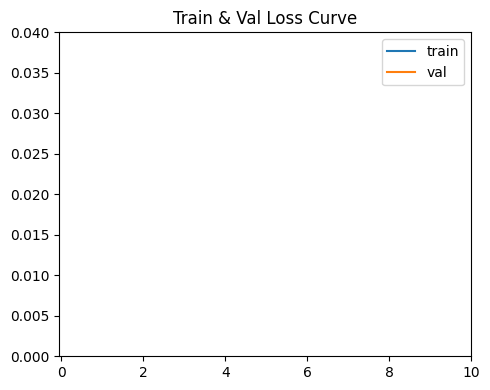

Epoch 002 | Train Loss: 0.0353 | Val Loss: 0.0255 | 
Save model checkpoint.


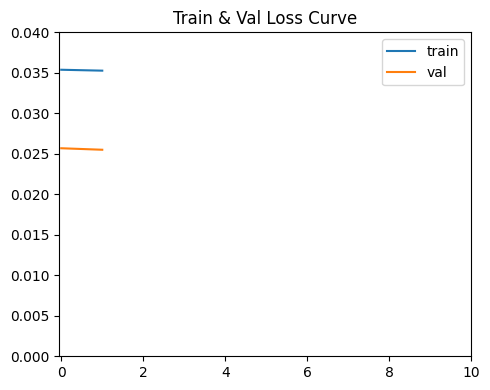

Epoch 003 | Train Loss: 0.0349 | Val Loss: 0.0241 | 
Save model checkpoint.


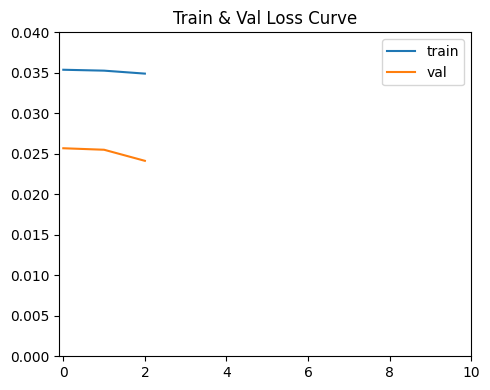

Epoch 004 | Train Loss: 0.0343 | Val Loss: 0.0230 | 
Save model checkpoint.


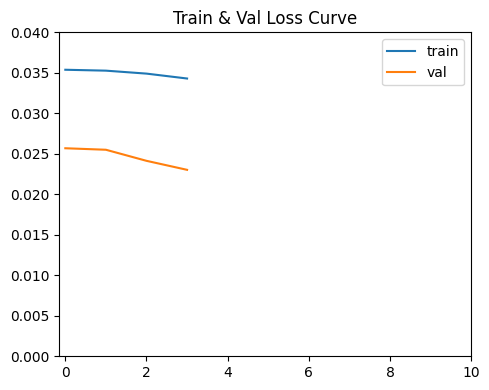

Epoch 005 | Train Loss: 0.0338 | Val Loss: 0.0225 | 
Save model checkpoint.


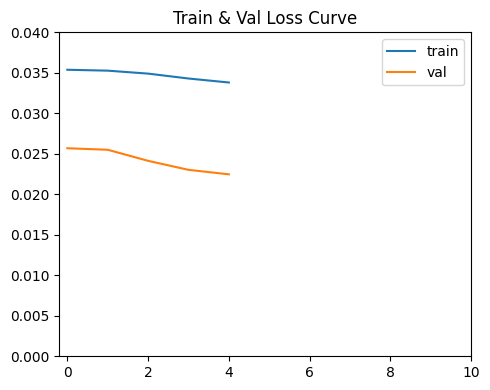

Epoch 006 | Train Loss: 0.0334 | Val Loss: 0.0235 | 


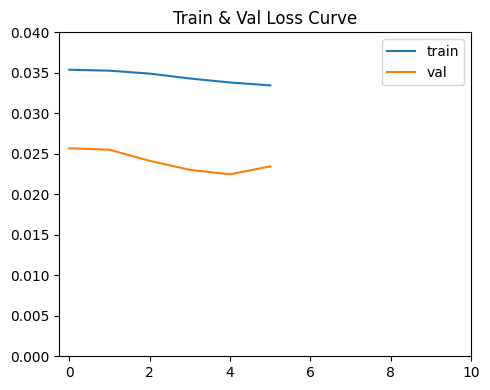

Epoch 007 | Train Loss: 0.0329 | Val Loss: 0.0216 | 
Save model checkpoint.


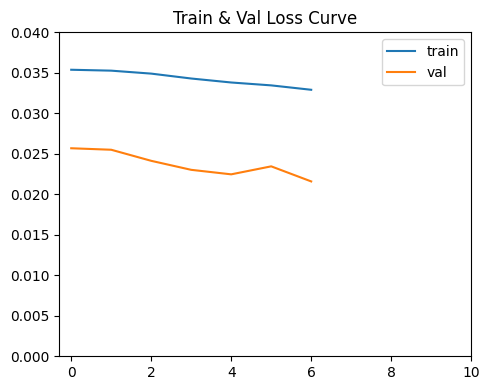

Epoch 008 | Train Loss: 0.0304 | Val Loss: 0.0200 | 
Save model checkpoint.


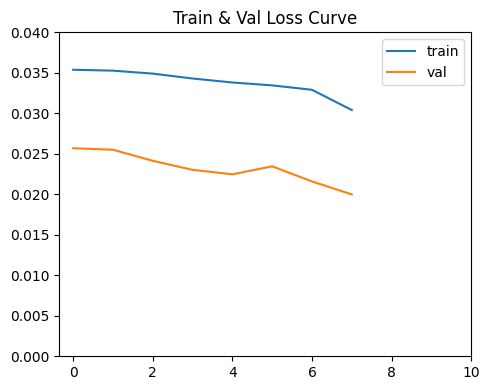

Epoch 009 | Train Loss: 0.0280 | Val Loss: 0.0188 | 
Save model checkpoint.


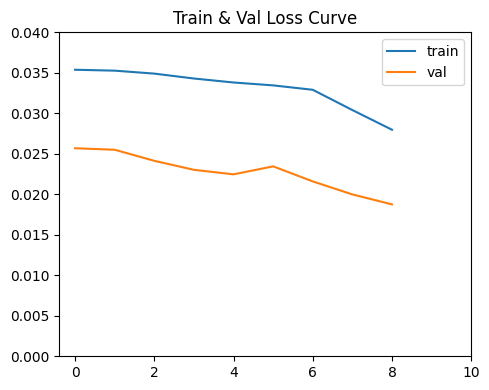

Epoch 010 | Train Loss: 0.0266 | Val Loss: 0.0177 | 
Save model checkpoint.


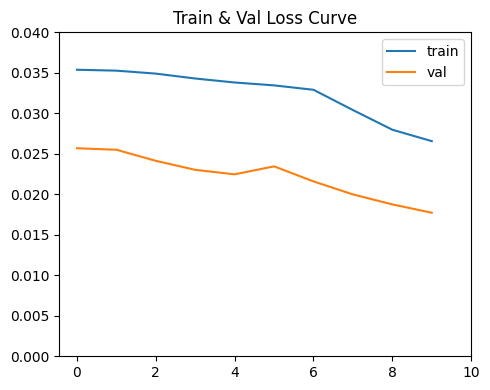

In [ ]:
# initialise model
model = UNet3D(in_channels=1, out_channels=3).to(device)

# optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# create directory to save checkpoints
os.makedirs("./model", exist_ok=True)

num_epochs = 10
best_val_loss = float("inf")

# weights for different loss functions
w_edge = 2.0
w_lapl = 1e+3

train_curve = []
val_curve = []

for epoch in tqdm(range(num_epochs)):
    # ---------------------------------------------------------
    # Training
    # ---------------------------------------------------------
    train_loss = train(
        model,
        train_loader,
        optimizer,
        vert_in=(vert_lv_in, vert_my_in, vert_rv_in),
        edge_in=(edge_lv_in, edge_my_in, edge_rv_in),
        w_edge=w_edge,
        w_lapl=w_lapl,
        device=device
    )

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------
    val_loss, vert_pred, point_gt = validate(
        model,
        val_loader,
        vert_in=(vert_lv_in, vert_my_in, vert_rv_in),
        device=device,
    )

    train_curve.append(train_loss)
    val_curve.append(val_loss)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
    )

    # ---------------------------------------------------------
    # Save the best model checkpoint
    # ---------------------------------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        # save model checkpoints
        print("Save model checkpoint.")
        torch.save(
            model.state_dict(),
            "./model/acdc_mesh_fit_unet.pth"
        )

        # save the validation example of prediction and ground truth
        face_lv_pred = face_lv_in[0].cpu().numpy()
        face_my_pred = face_my_in[0].cpu().numpy()
        face_rv_pred = face_rv_in[0].cpu().numpy()

        mesh_lv_pred = trimesh.Trimesh(vert_pred[0], face_lv_pred)
        mesh_my_pred = trimesh.Trimesh(vert_pred[1], face_my_pred)
        mesh_rv_pred = trimesh.Trimesh(vert_pred[2], face_rv_pred)

        pc_lv_gt = trimesh.PointCloud(point_gt[0])
        pc_my_gt = trimesh.PointCloud(point_gt[1])
        pc_rv_gt = trimesh.PointCloud(point_gt[2])

        mesh_lv_pred.export('./model/mesh_lv_pred.obj')
        mesh_my_pred.export('./model/mesh_my_pred.obj')
        mesh_rv_pred.export('./model/mesh_rv_pred.obj')

        pc_lv_gt.export('./model/point_lv_gt.obj')
        pc_my_gt.export('./model/point_my_gt.obj')
        pc_rv_gt.export('./model/point_rv_gt.obj')

    # ---------------------------------------------------------
    # Visualisation
    # ---------------------------------------------------------
    plt.figure(figsize=(5,4))
    plt.plot(train_curve, label='train')
    plt.plot(val_curve, label='val')
    plt.xticks(np.arange(0,num_epochs+1,2))
    plt.ylim(0.0,0.04)
    plt.legend()
    plt.title("Train & Val Loss Curve")
    plt.tight_layout()
    plt.show()

In [ ]:
# ---------------------------------------------------------
# visualise predicted mesh
# ---------------------------------------------------------
mesh_lv_pred = trimesh.load('./model/mesh_lv_pred.obj')
mesh_my_pred = trimesh.load('./model/mesh_my_pred.obj')
mesh_rv_pred = trimesh.load('./model/mesh_rv_pred.obj')

scene = heart_visualise(mesh_lv_pred, mesh_my_pred, mesh_rv_pred)
scene.show()

In [ ]:
# ---------------------------------------------------------
# predicted mesh overlapped with groud-truth points
# ---------------------------------------------------------
point_lv_gt = trimesh.load('./model/point_lv_gt.obj').vertices
point_my_gt = trimesh.load('./model/point_my_gt.obj').vertices
point_rv_gt = trimesh.load('./model/point_rv_gt.obj').vertices

point_lv = points_as_spheres(point_lv_gt, radius=0.005, color=(255,0,0))
point_my = points_as_spheres(point_my_gt, radius=0.005, color=(0,255,0))
point_rv = points_as_spheres(point_rv_gt, radius=0.005, color=(0,0,255))

scene.add_geometry(point_lv)
scene.add_geometry(point_my)
scene.add_geometry(point_rv)
scene.show()

## Next step: From 3D to 3D+t Mesh Fitting

In this practical session, we have focused on fitting a cardiac mesh to a **single 3D CMR volume**, providing a subject-specific representation of cardiac anatomy at one time point. A natural next step is to extend this framework to **3D+t mesh fitting**, where a sequence of meshes is fitted across the entire cardiac cycle.

A key challenge in 3D+t mesh fitting is maintaining **temporal consistency**. Although each cardiac phase can be fitted independently using the model developed in this session, this may lead to unrealistic jumps between neighbouring frames, local mesh distortions, or inconsistent vertex trajectories over time.

The longer-term goal is therefore to move beyond a sequence of independently fitted 3D shapes and develop a **temporally consistent 4D cardiac model** that captures both cardiac anatomy and motion throughout the cardiac cycle.